In [30]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

def pcaSweep(features_tensor, components=[32, 16, 8, 4]):
    x = features_tensor.numpy()
    x = RobustScaler().fit_transform(x)
    
    pca = PCA(n_components=max(components))
    full_reduced = pca.fit_transform(x)
    exp_var_ratios = pca.explained_variance_ratio_
    
    results = {}
    
    for n in sorted(components, reverse=True):
        reduced_n = full_reduced[:, :n]
        var_explained = exp_var_ratios[:n].sum() * 100
        
        results[n] = torch.from_numpy(reduced_n).float()
        
        print(f"n={n} | Varianza spiegata: {var_explained:.2f}%")
        
    return results

CURRENT_SEED = 79
checkpoint = torch.load(f"../extractedFeatures/extracted_features_seed_{CURRENT_SEED}.pt")
feat_originali = checkpoint['features']
pca_data = pcaSweep(feat_originali)

C:\Users\shali\AppData\Local\Temp\ipykernel_1816\3695618256.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"../extractedFeatures/extracted_fea

n=32 | Varianza spiegata: 97.45%
n=16 | Varianza spiegata: 95.44%
n=8 | Varianza spiegata: 92.12%
n=4 | Varianza spiegata: 87.10%


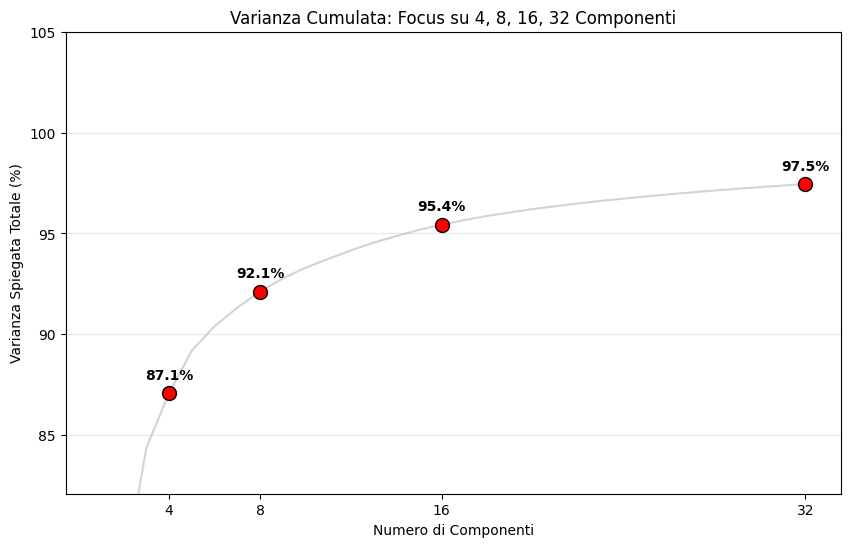

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plotPca(features_tensor, components=[4, 8, 16, 32]):
    x = features_tensor.numpy()
    x = RobustScaler().fit_transform(x)
    max_comp = max(components)
    pca = PCA(n_components=max_comp)
    pca.fit(x)
    cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_comp + 1), cum_var, color='lightgray', zorder=1)
    for n in components:
        current_var = cum_var[n-1]
        plt.scatter(n, current_var, color='red', s=100, edgecolors='black', zorder=2)
        plt.annotate(f'{current_var:.1f}%', (n, current_var), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
    plt.title('Varianza Cumulata')
    plt.xlabel('Numero di Componenti')
    plt.ylabel('Varianza Spiegata')
    plt.xticks(components)
    plt.ylim(min(cum_var[min(components)-1:] ) - 5, 105)
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

plotPca(feat_originali)